# The file SouvenirSales contains monthly sales for a souvenir shop at a beach resort town in Queensland, Australia, between 1995 and 2001.
# Back in 2001, the store wanted to use the data to forecast sales for the next 12 months (year 2002).They hired an analyst to generate forecasts. The analyst first partitioned the data into training and test periods, with the test set containing the last 12 months of data (year 2001).
# She then fit a regression model to sales, using the training period.


# A. Create a .csv file out of the given data and put it online (you will use a link to it in your program).


In [1]:

!pip install gdown
import pandas as pd
import gdown

In [2]:
url = 'https://drive.google.com/uc?id=1D1FxfY2PeZj3MPRSAs_ygqjEouEF8Epz&export=download'
output = 'data.csv'

gdown.download(url, output, quiet=False)

df = pd.read_csv('data.csv', delimiter=';')
print(df)


Downloading...
From: https://drive.google.com/uc?id=1D1FxfY2PeZj3MPRSAs_ygqjEouEF8Epz&export=download
To: /content/data.csv
100%|██████████| 1.38k/1.38k [00:00<00:00, 2.34MB/s]

      Date     Sales
0   Jan.95   1664,81
1   Feb.95   2397,53
2   Mar.95   2840,71
3   Apr.95   3547,29
4   May.95   3752,96
..     ...       ...
79  Aug.01  28586,52
80  Sep.01  30505,41
81  Oct.01  30821,33
82  Nov.01  46634,38
83  Dec.01  104660,7

[84 rows x 2 columns]


In [3]:
print(df['Sales'])

df['Sales'] = df['Sales'].str.replace(',', '.').astype(float)


0      1664,81
1      2397,53
2      2840,71
3      3547,29
4      3752,96
        ...   
79    28586,52
80    30505,41
81    30821,33
82    46634,38
83    104660,7
Name: Sales, Length: 84, dtype: object


In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%b.%y')

In [5]:
print(df)

         Date      Sales
0  1995-01-01    1664.81
1  1995-02-01    2397.53
2  1995-03-01    2840.71
3  1995-04-01    3547.29
4  1995-05-01    3752.96
..        ...        ...
79 2001-08-01   28586.52
80 2001-09-01   30505.41
81 2001-10-01   30821.33
82 2001-11-01   46634.38
83 2001-12-01  104660.70

[84 rows x 2 columns]


# B. Plot the data.

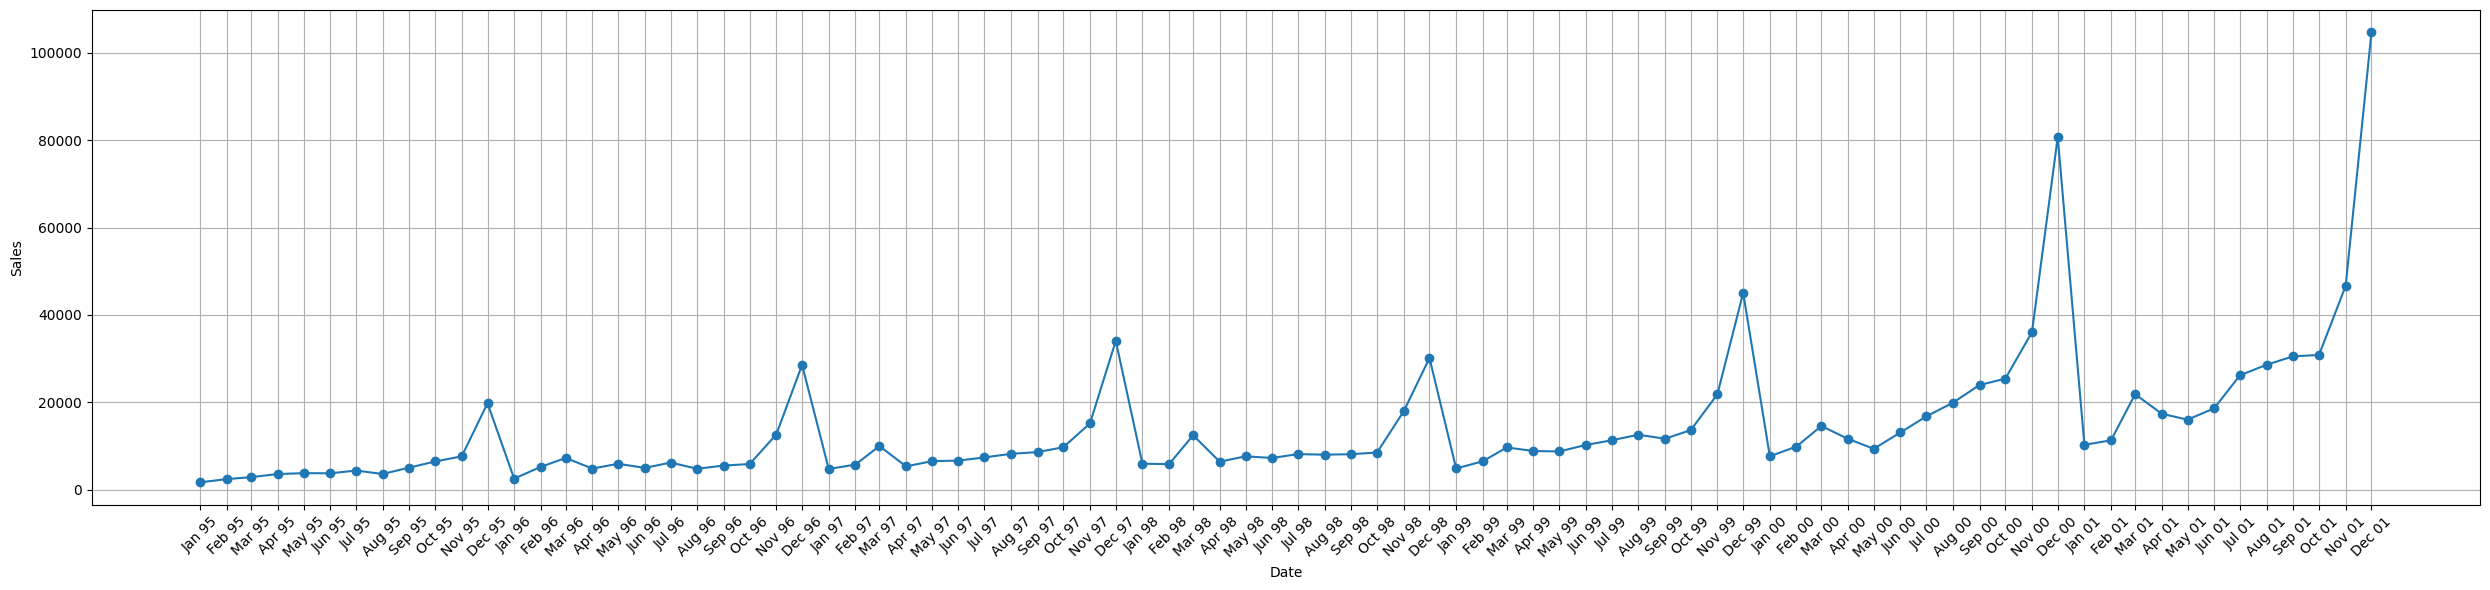

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 6))


plt.plot(df['Date'], df['Sales'], marker='o', linestyle='-')

# Установка меток на оси X для каждого месяца
plt.xticks(df['Date'], df['Date'].dt.strftime('%b %y'), rotation=45)

plt.xlabel('Date')
plt.ylabel('Sales')

# Включаем сетку
plt.grid(True)

plt.tight_layout()
plt.show()



#Looking at the graph, you can see sales jumping in November and December, followed by a sharp drop in sales in January to +- standard levels for the year. You can also see a slight jump in sales in March, after which the next month's figure becomes slightly higher than the January sales figure or remains the same.

#C. 1) Run the ADF test and check if the process is stationary. If not, apply differencing.

I will use Augmented Dickey–Fuller (ADF) Test to check if the data is stationary.

The null hypothesis: there is a unit root present in a
time series.

The augmented Dickey-Fuller (ADF)
test helps us determine if a time
series is stationary by testing for the
presence of a unit root.
If a unit root is present, the time
series is not stationary.


In [7]:
from statsmodels.tsa.stattools import adfuller


ADF_result = adfuller(df['Sales'])
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')



ADF Statistic: 2.316544104902997
p-value: 0.9989654538596132


This prints an ADF statistic of 2.316544104902997 and a p-value of
0.9989654538596132. The ADF statistic is not negative number,
and with a p-value greater than 0.05, we can not
reject the null hypothesis.the series is not
stationary.

Conclusion: the dataset is not stationary.

#Differencing

#Data Transformation

ADF Statistic: -2.1654800923661037
p-value: 0.21901181581867263
Performing 2 order differencing...
ADF Statistic: -8.661375066146507
p-value: 4.812257360867916e-14
Performing 3 order differencing...
ADF Statistic: -11.546182792722545
p-value: 3.536616925667341e-21
The series is now stationary!


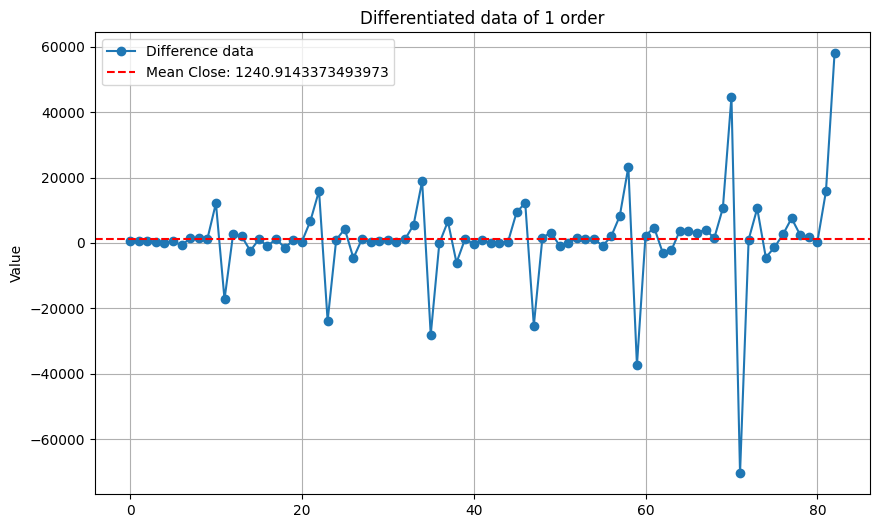

In [8]:
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Differencing
def diff_and_ADF(df, n=1):
    diff_data = np.diff(df['Sales'], n)

    # Проверка стационарности после дифференцирования
    ADF_result = adfuller(diff_data)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}')

    if ADF_result[1] < 0.05 and ADF_result[0] < -10:
        print('We can reject the null hypothesis (the series is stationary)!')
        return diff_data

    mean_close = diff_data.mean()

    plt.figure(figsize=(10, 6))
    plt.plot(diff_data, marker='o', linestyle='-', label='Difference data')
    plt.axhline(mean_close, color='red', linestyle='--', label=f'Mean Close: {mean_close}')
    plt.title(f'Differentiated data of {n} order')
    plt.ylabel('Value')
    plt.grid(True)
    plt.legend()

    # Дифференцирование до тех пор, пока p-value не станет меньше 0.05 и ADF Statistic не станет меньше -10
    while ADF_result[1] > 0.05 or ADF_result[0] > -10:
        n += 1
        print(f'Performing {n} order differencing...')
        diff_data = np.diff(diff_data)
        ADF_result = adfuller(diff_data)
        print(f'ADF Statistic: {ADF_result[0]}')
        print(f'p-value: {ADF_result[1]}')

    print('The series is now stationary!')

    return diff_data

diff_data = diff_and_ADF(df)


In [9]:
print(diff_data)

[ 5.5294000e+02 -7.6431000e+02  2.5702000e+02  9.1698000e+02
 -2.0912300e+03  3.6568900e+03 -2.2925700e+03 -1.7072000e+02
  1.1203030e+04 -4.0390500e+04  4.9366840e+04 -2.0626360e+04
 -3.7744800e+03  7.9599700e+03 -5.5583500e+03  4.2217100e+03
 -4.8320700e+03  4.8260000e+03 -2.5768600e+03  6.8319200e+03
  2.7503500e+03 -4.8943000e+04  6.4576650e+04 -2.1540970e+04
 -1.2177090e+04  1.4748200e+04 -6.8897300e+03  1.6297300e+03
 -4.7227000e+02 -5.3863000e+02  1.1512300e+03  3.6232300e+03
  9.1038200e+03 -6.0496910e+04  7.5082470e+04 -2.1320200e+04
 -1.9371340e+04  1.9948980e+04 -8.9145500e+03  2.9045600e+03
 -2.3192800e+03  1.2942200e+03  1.4050000e+01  8.7844900e+03
 -6.2925300e+03 -4.0249310e+04  6.4418880e+04 -2.5406410e+04
 -5.5110900e+03  4.7049400e+03  8.6711000e+02 -2.0059500e+03
  6.2864000e+02 -2.3991000e+03  5.0748300e+03  3.3613900e+03
  8.7776400e+03 -7.5707600e+04  1.0036456e+05 -3.7206270e+04
 -1.0153830e+04  8.3960800e+03  5.2880000e+03 -6.1031400e+03
 -3.9602000e+02  1.38380

Great!
Now our data is stationary.
Because ADF Statistical: -8.661375066146507, and this is quite a large
negative numberand p_value is less than 0.05.

Therefore, we reject the null hypothesis, and we can
say that this process has no unit root and is thus
stationary

#D. Plot the ACF. What can you see?

#Autocorrelation


●Autocorrelation of a time series is the idea that a
value in a time series at one given point in time may
have a correlation to the value at another point in
time. It is the similarity between observations as a
function of the time lag between them.

● The lag is the number of timesteps separating two
values.

● More formally, autocorrelation is the correlation of a
value with a delayed copy of itself as a function of
the delay.

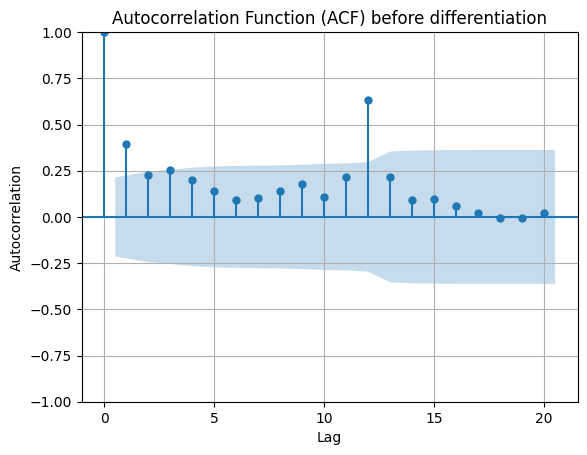

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['Sales'], lags=20)
plt.title('Autocorrelation Function (ACF) before differentiation')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

● The autocorrelation coefficients slowly decrease as
the lag increases, which is a clear indicator that our
random walk is not a stationary process.

● The shaded area represents a confidence interval.
If a point is within the shaded area, then it is not
significantly different from 0. Otherwise, the
autocorrelation coefficient is significant(as in the left half of this plot ).


#But the ACF graph of non-stationary data won't give us much information!

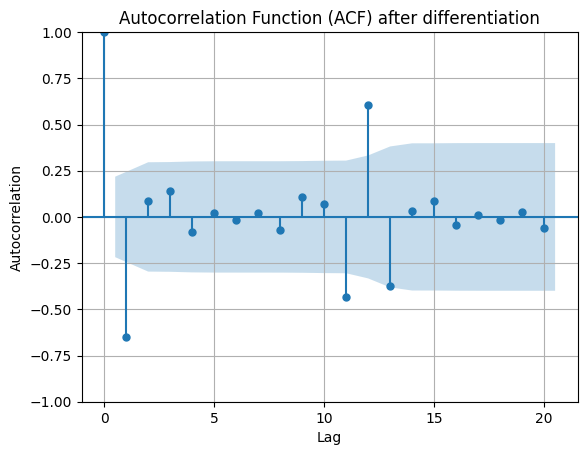

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(diff_data, lags=20)
plt.title('Autocorrelation Function (ACF) after differentiation')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()



● There are significant autocorrelation coefficients
beyond lag 0. Therefore, we know that our process **is
not a random walk**.

● The coefficients are decaying exponentially as the lag
increases. increases. Therefore, there is no lag at which
the coefficients abruptly become non-significant. So, it
is **not a moving average process** and that we are likely
studying an **autoregressive process**.

#E. Plot the PACF. After what lag the coefficients become abruptly nonsignificant?

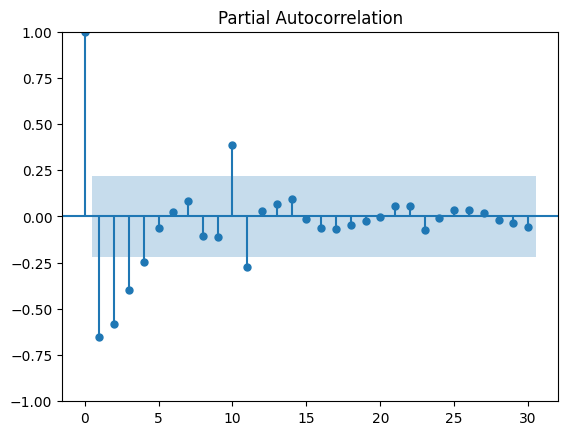

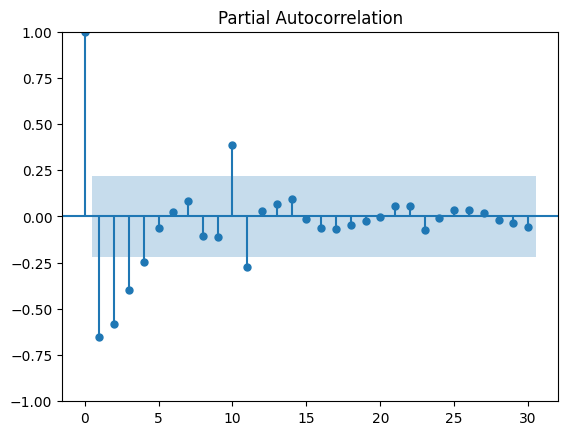

In [12]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(diff_data, lags=30)

#After 11 lag the coefficients become abruptly nonsignificant



#F. Separate your series into a train set and a test set

In [13]:

train = diff_data[:-12]
test= diff_data[-12:]

print("Size of train:", len(train))
print("Size of test:", len(test))


Size of train: 69
Size of test: 12


In [14]:
print(diff_data)

[ 5.5294000e+02 -7.6431000e+02  2.5702000e+02  9.1698000e+02
 -2.0912300e+03  3.6568900e+03 -2.2925700e+03 -1.7072000e+02
  1.1203030e+04 -4.0390500e+04  4.9366840e+04 -2.0626360e+04
 -3.7744800e+03  7.9599700e+03 -5.5583500e+03  4.2217100e+03
 -4.8320700e+03  4.8260000e+03 -2.5768600e+03  6.8319200e+03
  2.7503500e+03 -4.8943000e+04  6.4576650e+04 -2.1540970e+04
 -1.2177090e+04  1.4748200e+04 -6.8897300e+03  1.6297300e+03
 -4.7227000e+02 -5.3863000e+02  1.1512300e+03  3.6232300e+03
  9.1038200e+03 -6.0496910e+04  7.5082470e+04 -2.1320200e+04
 -1.9371340e+04  1.9948980e+04 -8.9145500e+03  2.9045600e+03
 -2.3192800e+03  1.2942200e+03  1.4050000e+01  8.7844900e+03
 -6.2925300e+03 -4.0249310e+04  6.4418880e+04 -2.5406410e+04
 -5.5110900e+03  4.7049400e+03  8.6711000e+02 -2.0059500e+03
  6.2864000e+02 -2.3991000e+03  5.0748300e+03  3.3613900e+03
  8.7776400e+03 -7.5707600e+04  1.0036456e+05 -3.7206270e+04
 -1.0153830e+04  8.3960800e+03  5.2880000e+03 -6.1031400e+03
 -3.9602000e+02  1.38380

 # G. Make forecasts over the test set. Use the historical mean method, last known value method, and an AR(p) model for an appropriate p. Apply a window of length 2.

Parameters:
— train_len is the number of data points that can be
used to fit a model;
— horizon is the length of the test set and represents
how many values must be predicted;
— window specifies how many timesteps are predicted
at a time;
— method specifies what model to use.

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str,p:int) -> list:
    total_len = train_len + horizon
    pred_values = []
    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean

    elif method == 'last':
      pred_last_value = []
      for i in range(train_len, total_len, window):
        last_value = df[:i].iloc[-1].values[0]
        pred_last_value.extend(last_value for _ in range(window))

      return pred_last_value
    elif method == 'AR':
      pred_AR = []
      for i in range(train_len, total_len, window):
        model = SARIMAX(df[:i], order=(p, 0, 0))
        res = model.fit(disp=False)
        predictions = res.get_prediction(0, i + window - 1)
        pred = predictions.predicted_mean.iloc[-window:]
        pred_AR.extend(pred)
      return pred_AR

    return pred_values

horizon = len(test)  # Горизонт прогнозирования
window = 2  # Длина окна


diff_data_df = pd.DataFrame(diff_data)


# Вызов функции для получения прогнозов разными методами
pred_values_mean = rolling_forecast(diff_data_df, len(train), horizon, window, 'mean',p=11)
pred_values_last = rolling_forecast(diff_data_df, len(train), horizon, window, 'last',p=11)

print(pred_values_mean)
print(pred_values_last)

pred_values_AR = rolling_forecast(diff_data_df, len(train), horizon, window, 'AR',p=11)
print(pred_values_AR)

[497.8695652173917, 497.8695652173917, 1011.1500000000003, 1011.1500000000003, -201.9168493150687, -201.9168493150687, 56.70426666666642, 56.70426666666642, -62.7624675324678, -62.7624675324678, -16.625696202531834, -16.625696202531834]
[24887.979999999992, 24887.979999999992, 186677.49, 186677.49, -24565.79, -24565.79, 853.3100000000013, 853.3100000000013, -10072.130000000008, -10072.130000000008, -1090.489999999998, -1090.489999999998]


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/stat

[-93585.18481910403, 96972.71817141984, -62300.9324877215, -23308.52816809606, 7468.115240141255, 7868.6308328681735, -12614.870604288939, 4152.21614226955, -1308.4466610022355, 4932.679763147225, 12349.735458176134, 28671.70263972362]


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# H.Plot your forecasts.

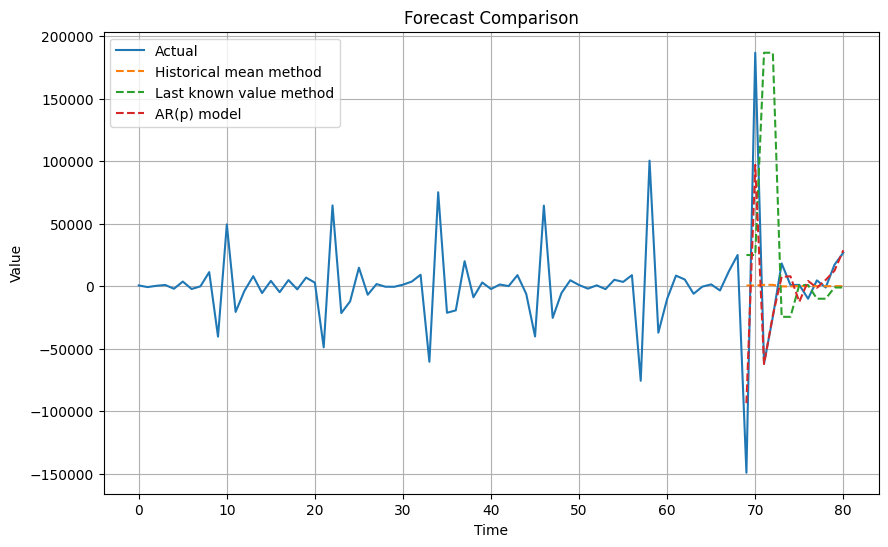

In [16]:


plt.figure(figsize=(10, 6))
plt.plot(diff_data, label='Actual')

#Historical mean method
plt.plot(np.arange(len(train), len(train) + len(test)),pred_values_mean, label='Historical mean method', linestyle='--')

#Last known value method
plt.plot(np.arange(len(train), len(train) + len(test)),pred_values_last, label='Last known value method', linestyle='--')

#AR(p) model
plt.plot(np.arange(len(train), len(train) + len(test)),pred_values_AR, label='AR(p) model', linestyle='--')

plt.title('Forecast Comparison')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# I. Measure the MSE. Which method is the best?

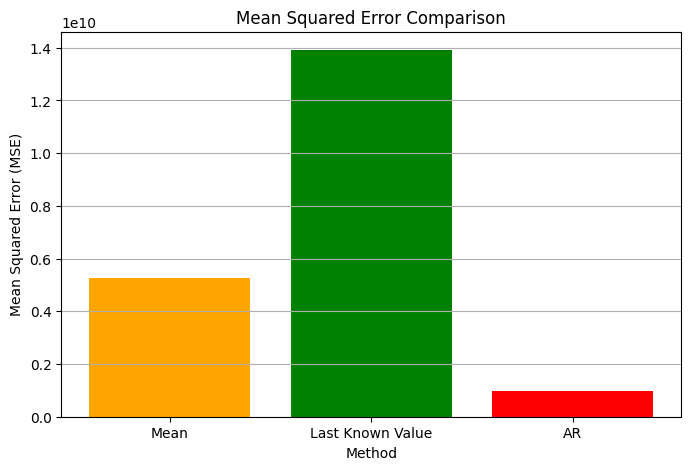

In [17]:
pred_df = pd.DataFrame()
pred_df['pred_mean'] = pred_values_mean
pred_df['pred_last_value'] = pred_values_last
pred_df['pred_AR'] =pred_values_AR


from sklearn.metrics import mean_squared_error
mse_mean =mean_squared_error(test,pred_df['pred_mean'])
mse_last = mean_squared_error(test,pred_df['pred_last_value'])
mse_AR = mean_squared_error(test,pred_df['pred_AR'])



# Список методов
methods = ['Mean', 'Last Known Value', 'AR']

# Список среднеквадратичных ошибок
mse_values = [mse_mean, mse_last, mse_AR]


plt.figure(figsize=(8, 5))
plt.bar(methods, mse_values, color=['orange', 'green', 'red'])
plt.xlabel('Method')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean Squared Error Comparison')
plt.grid(axis='y')
plt.show()

#The best method out of 3 suggested - AR(11).
#BUT

#**Before moving on to the next step, I want to do the differentiation more times until I reach a value of ADF Statistic<-25**

# C. 2)

ADF Statistic: -2.1654800923661037
p-value: 0.21901181581867263
Performing 2 order differencing...
ADF Statistic: -8.661375066146507
p-value: 4.812257360867916e-14
Performing 3 order differencing...
ADF Statistic: -11.546182792722545
p-value: 3.536616925667341e-21
Performing 4 order differencing...
ADF Statistic: -7.643782448847594
p-value: 1.8658041822130523e-11
Performing 5 order differencing...
ADF Statistic: -3.7755595610883583
p-value: 0.0031675080299275347
Performing 6 order differencing...
ADF Statistic: -10.395189326549687
p-value: 1.973627755953928e-18
Performing 7 order differencing...
ADF Statistic: -6.763624319994583
p-value: 2.752198329572308e-09
Performing 8 order differencing...
ADF Statistic: -10.291803829521157
p-value: 3.554053072675525e-18
Performing 9 order differencing...
ADF Statistic: -11.892645229018006
p-value: 5.819737860509018e-22
Performing 10 order differencing...
ADF Statistic: -12.38881490172971
p-value: 4.8408829804534016e-23
Performing 11 order differen

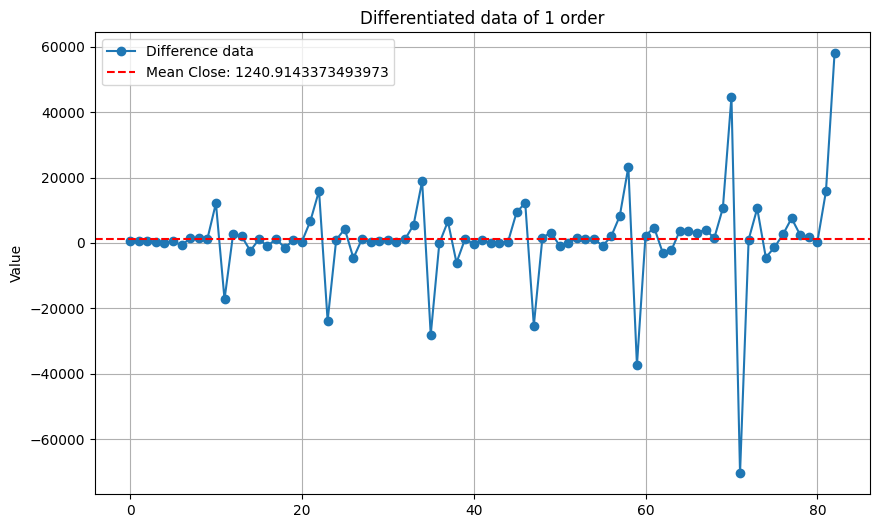

In [41]:
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Differencing
def diff_and_ADF(df, n=1):
    diff_data = np.diff(df['Sales'], n)

    # Проверка стационарности после дифференцирования
    ADF_result = adfuller(diff_data)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}')

    if ADF_result[1] < 0.05 and ADF_result[0] < -10:
        print('We can reject the null hypothesis (the series is stationary)!')
        return diff_data

    mean_close = diff_data.mean()

    plt.figure(figsize=(10, 6))
    plt.plot(diff_data, marker='o', linestyle='-', label='Difference data')
    plt.axhline(mean_close, color='red', linestyle='--', label=f'Mean Close: {mean_close}')
    plt.title(f'Differentiated data of {n} order')
    plt.ylabel('Value')
    plt.grid(True)
    plt.legend()


    #это понадобится для обратного дифференцирования
    list_of_diff_data=[]
    # Дифференцирование до тех пор, пока p-value не станет меньше 0.05 и ADF Statistic не станет меньше -10
    while ADF_result[1] > 0.05 or ADF_result[0] > -15:
        n += 1
        print(f'Performing {n} order differencing...')
        diff_data = np.diff(diff_data)
        list_of_diff_data.append(diff_data)
        ADF_result = adfuller(diff_data)
        print(f'ADF Statistic: {ADF_result[0]}')
        print(f'p-value: {ADF_result[1]}')

    print('The series is now stationary!')

    return diff_data,list_of_diff_data

diff_data_second,list_of_diff_data = diff_and_ADF(df)


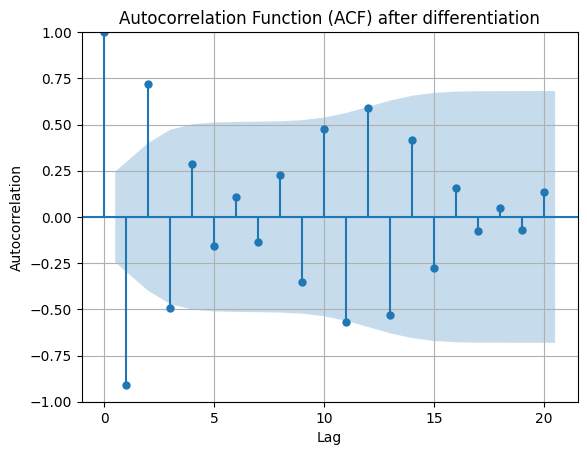

In [42]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(diff_data_second, lags=20)
plt.title('Autocorrelation Function (ACF) after differentiation')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()



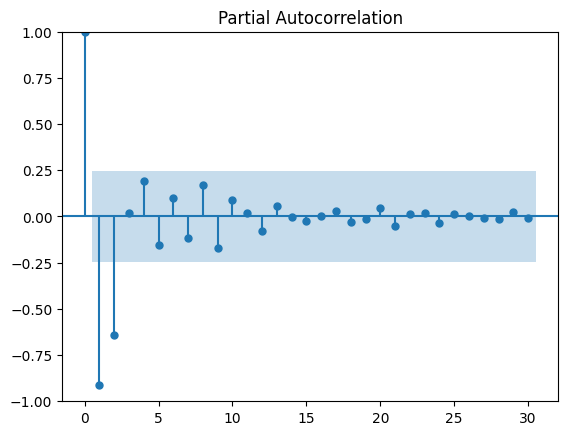

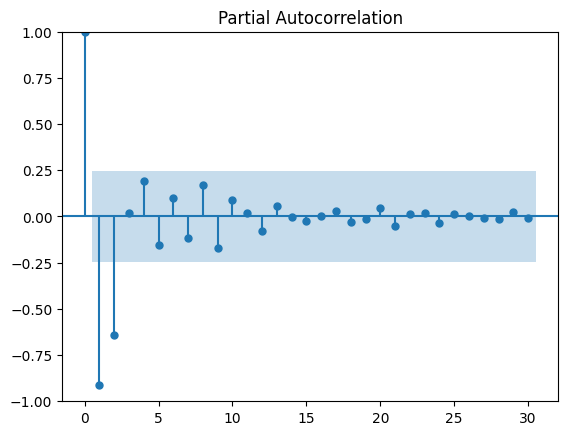

In [43]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(diff_data_second, lags=30)

We see that p=2

In [44]:
diff_data_df_second = pd.DataFrame(diff_data_second)


# Вызов функции для получения прогнозов разными методами
pred_values_mean_second = rolling_forecast(diff_data_df_second, len(train), horizon, window, 'mean',p=2)
pred_values_last_second = rolling_forecast(diff_data_df_second, len(train), horizon, window, 'last',p=2)

print(pred_values_mean_second)
print(pred_values_last_second)

pred_values_AR_second = rolling_forecast(diff_data_df_second, len(train), horizon, window, 'AR',p=2)
print(pred_values_AR_second)

[7154506.195192291, 7154506.195192291, -13156054.381666686, -13156054.381666686, -16066848.753571441, -16066848.753571441, 210401.84103446172, 210401.84103446172, 42169722.84649999, 42169722.84649999, 58716242.0032258, 58716242.0032258]
[3533990091.2900014, 3533990091.2900014, 1089343649.7800007, 1089343649.7800007, 286500146.1700003, 286500146.1700003, 1447903533.0699997, 1447903533.0699997, 5774206823.91, 5774206823.91, 9269166686.0, 9269166686.0]
[-1984437287.6690083, 251355848.43827963, 40871359.80679965, -1071642552.20995, -83380156.24039465, -107410588.17337099, -2086269034.2860951, 2405650911.6880913, -7564048732.860892, 8492292395.592565, -9409187953.203247, 8617385183.22002]


Size of train: 52
Size of test: 12
52 64


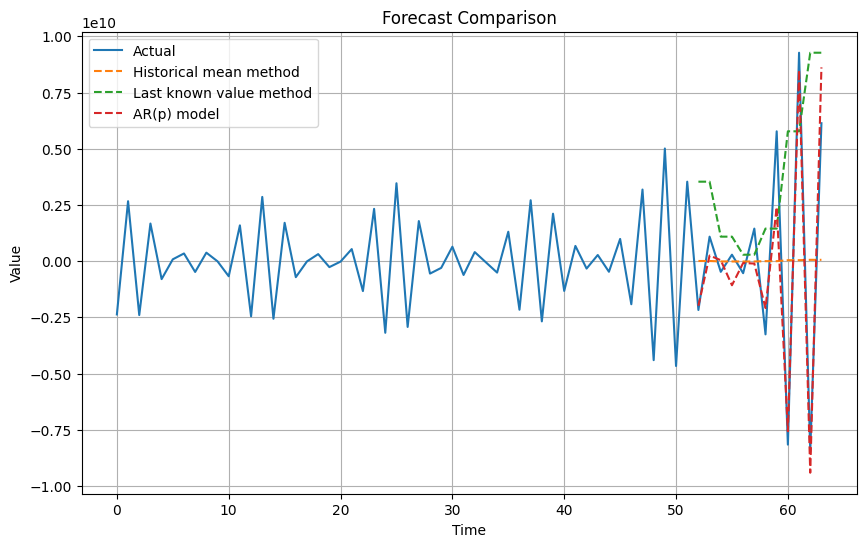

In [45]:


train_second = diff_data_second[:-12]
test_second= diff_data_second[-12:]

print("Size of train:", len(train))
print("Size of test:", len(test))

plt.figure(figsize=(10, 6))
plt.plot(diff_data_second, label='Actual')
print(len(train), len(train) + len(test))
#Historical mean method
plt.plot(np.arange(len(train), len(train) + len(test)),pred_values_mean_second, label='Historical mean method', linestyle='--')

#Last known value method
plt.plot(np.arange(len(train), len(train) + len(test)),pred_values_last_second, label='Last known value method', linestyle='--')

#AR(p) model
plt.plot(np.arange(len(train), len(train) + len(test)),pred_values_AR_second, label='AR(p) model', linestyle='--')

plt.title('Forecast Comparison')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

[2.6213471095610393e+19, 5.126785215558454e+19, 2.1834252490207183e+18]


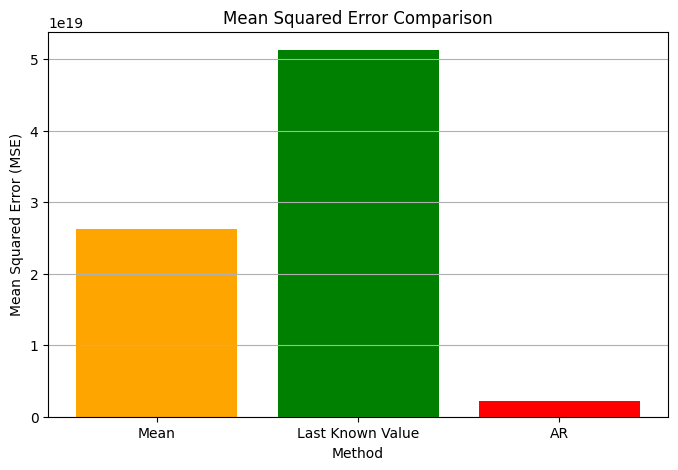

In [46]:
pred_df_second = pd.DataFrame()
pred_df_second['pred_mean'] = pred_values_mean_second
pred_df_second['pred_last_value'] = pred_values_last_second
pred_df_second['pred_AR'] =pred_values_AR_second


from sklearn.metrics import mean_squared_error

mse_mean_second =mean_squared_error(test,pred_df_second['pred_mean'])
mse_last_second = mean_squared_error(test,pred_df_second['pred_last_value'])
mse_AR_second = mean_squared_error(test,pred_df_second['pred_AR'])



# Список методов
methods = ['Mean', 'Last Known Value', 'AR']

# Список среднеквадратичных ошибок
mse_values_second = [mse_mean_second, mse_last_second, mse_AR_second]
print(mse_values_second)

plt.figure(figsize=(8, 5))
plt.bar(methods, mse_values_second, color=['orange', 'green', 'red'])
plt.xlabel('Method')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean Squared Error Comparison')
plt.grid(axis='y')
plt.show()

#And now I want to compare the MSE of the past result and this one

In [47]:
for i in range(len(mse_values_second)):
  print(mse_values_second[i]<mse_values[i],' - ', methods[i])

False  -  Mean
True  -  Last Known Value
True  -  AR


Great!
We see that the MSE value has decreased in 2 out of 3 methods. And also on the graphs you can visually see that the best method is AR(2) and it worked better than the previous AR(11).

# J.Reverse differencing if needed, plot the best forecast and calculate the MAE

#'Performing 20 order differencing...
#ADF Statistic: -15.807521421951765
#p-value: 1.0561696623274975e-28
#The series is now stationary!'

We saw it in C) 2.


In [74]:

# Обратное дифференцирование
def inverse_diff(list_of_diff_data, initial_data):
    result = initial_data
    for diff_data in reversed(list_of_diff_data):
        result = np.concatenate(([result[0]], np.cumsum(diff_data) + result[0]))
    return result


initial_data = df['Sales'].values

undiff_data = inverse_diff(list_of_diff_data, initial_data)




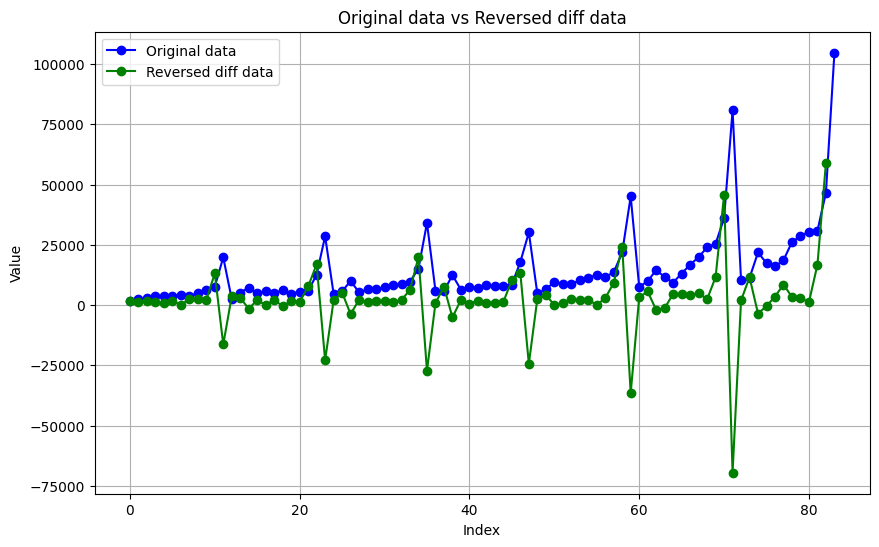

In [75]:
# Визуализация обратного дифференцирования
plt.figure(figsize=(10, 6))
plt.plot(df['Sales'], marker='o', linestyle='-', label='Original data', color='blue')
plt.plot(undiff_data, marker='o', linestyle='-', label='Reversed diff data', color='green')
plt.title('Original data vs Reversed diff data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


In [79]:
from sklearn.metrics import mean_absolute_error
mae_AR_undiff =mean_absolute_error(undiff_data[-12:],test)

print(mae_AR_undiff)

3922185762.255833


#K.Now, compute a forecast for January 2002

In [ ]:
import matplotlib.pyplot as plt

# Получение прогнозов AR(2)
pred_values_AR_2002 = rolling_forecast(diff_data_df_second, 12, horizon, window, 'AR', p=2)

# Рисование графиков
plt.figure(figsize=(10, 6))

# Фактические данные
plt.plot(diff_data_second, label='Actual')

# Прогнозы AR(2)
plt.plot(np.arange(len(train) + len(test), len(train) + len(test) + 12), pred_values_AR_2002,
         label='AR(2) method', linestyle='--')

plt.title('Forecast Comparison')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()
